In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

In [2]:
twohitfreq_path = "data/pancan_twohitfreq.tsv"
    # following datasets exported from R
twohitp_path = "data/dndscv_tsgs_twohit_pvals.tsv"
twohitc_path = "data/dndscv_tsgs_twohit_cis.tsv"
onehitp_path = "data/dndscv_tsgs_onehit_pvals.tsv"
onehitc_path = "data/dndscv_tsgs_onehit_cis.tsv"
globaldnds_path = "data/globaldnds.tsv"

In [3]:
twohitfreq = pd.read_csv(twohitfreq_path, sep='\t')
twohitp = pd.read_csv(twohitp_path, sep='\t')
twohitc = pd.read_csv(twohitc_path, sep = '\t')
onehitp = pd.read_csv(onehitp_path, sep='\t')
onehitc = pd.read_csv(onehitc_path, sep='\t')
globaldnds = pd.read_csv(globaldnds_path, sep='\t')

In [4]:
def config_rcparams():
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = ['arial']
    plt.rcParams['svg.fonttype'] = 'none' 
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.cal'] = 'arial'
    plt.rcParams['mathtext.rm'] = 'arial'
    plt.rcParams['axes.linewidth'] = 0.7
    plt.rcParams['xtick.major.width'] = 0.7
    plt.rcParams['ytick.major.width'] = 0.7
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3

---

# Fig 2A

In [5]:
# Preparing dataframes

twohitfreq = twohitfreq.copy()
twohitfreq["Hugo_Symbol"] = twohitfreq["Hugo_Symbol"].astype(str)
twohitfreq = twohitfreq[twohitfreq["Hugo_Symbol"] != "nan"]
twohitfreq = twohitfreq.rename(columns={"Hugo_Symbol": "gene_name"})

high = twohitfreq[(twohitfreq['2hitfreq']>0.4)&(twohitfreq['FDR']<0.05)]['gene_name'].unique()

# CDKN2A in TCGA refers to p16 (matched gene ID ie ENSG00000147889), hence renaming here  
    #https://genome.ucsc.edu/cgi-bin/hgSearch?search=CDKN2A.p14arf&hgsid=3530960517_pLXskXobxr8C3Xqc1sfHAriPa2Jy&db=hg38&token=0.Cpb_GOZ-CX6BZAwl1UpM1_Yo6LdC8qCpkyghSYiXk3E7TGJfDroZnbvHLOibo1xgKCvhP1wwM_AznDAowWY6h40KESXgCNPkXNprujCs1QgBdj17E54hMB7xaZOMfsDLOOvL62XP0mMhNXdRcILnFtc81BlUgsB4-wmhwlz2RH5sT8ugJBgGHJW2_PxkVqX_P-8_c_IWS5dOr3o0LFZzSpP_0K6cij2iLf8BkKPwFzbNtAZhCnzAVVxpj-mYitfVVzunfP6GEBpL8VaamtZCIdQ7Yo43QNlYofF1F30eROTvXyg_UsVfNFMgGIx8UIE3wf5SWTZfWCHCSeYBlaMmrrxeBJTgNMGKi54XEQw2ru-mWrHrr5b5cVWVnS3RnBn2bKRZFWHA28vYeiN-KxOZWCA4Ylxz7izd5q9uw8B-fKp8wC4h1qFVH-pdEKZsvOzDOmAWaWDKSjU4oDiNT6ueM6LRlam8MwphhzsUtxP_FgqZo-s_mH2P8GMQ8B445xh6QVPbZlZaJs_EQlcVUnebS9GzIQ_2Sl6QFEoegknPe8nnPLc-iWNsX7yizX2JBXMPrx4LAUHD3k_MUdFTwG669HRWQ7BfFRA0al_HxFWMXCioX_nAHNtiwxsWi4BXcjqvSk_PoS4rNrjHaGOZgMPcYF9xBqeoZxLncsXCWhtZz-lloBGRQ1z044FeE5-WpqHgtSeewuDDc0Rdhtew5ItwPD2cO3yxDKDsn7onV7Tf5q1qLneZKvWIAaKGWbTOxNbaR5InC2_3s724OulZOOApLr25Uh-KTX8DTQZs4IP2vs3t9QfQoUVdXOSbeqlteGG6dcxwItDq-tbrXoYbJjEIH7tUtNe1bSikbDayfF3B_h6qauZm6-2LDM4F_CSOoXVIgSSqdUfVhSW29egoqMrDwg.7lJJsB17cQ8MUjSbwrb6ZA.c60dad6931d52fce2940b58aa3b3d58f3751e8d0fb8545c0907ea5cea337be5b
    #https://www.oatext.com/aberrant-expression-of-p16ink4a-in-human-cancers-a-new-biomarker.php
    
p = twohitp[['gene_name','qmis_cv','qtrunc_cv']].rename(columns={'qmis_cv':'mis','qtrunc_cv':'tru'}).melt(id_vars='gene_name',value_vars=['mis','tru']).rename(columns={'variable':'class','value':'qval'})
twohit = pd.merge(twohitc,p,on=['gene_name','class'])
twohit = twohit[twohit.gene_name!='CDKN2A.p14arf']
twohit['gene_name'] = twohit['gene_name'].replace({'CDKN2A.p16INK4a':'CDKN2A'})

p = onehitp[['gene_name','qmis_cv','qtrunc_cv']].rename(columns={'qmis_cv':'mis','qtrunc_cv':'tru'}).melt(id_vars='gene_name',value_vars=['mis','tru']).rename(columns={'variable':'class','value':'qval'})
onehit = pd.merge(onehitc,p,on=['gene_name','class'])
onehit = onehit[onehit.gene_name!='CDKN2A.p14arf']
onehit['gene_name'] = onehit['gene_name'].replace({'CDKN2A.p16INK4a':'CDKN2A'})

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


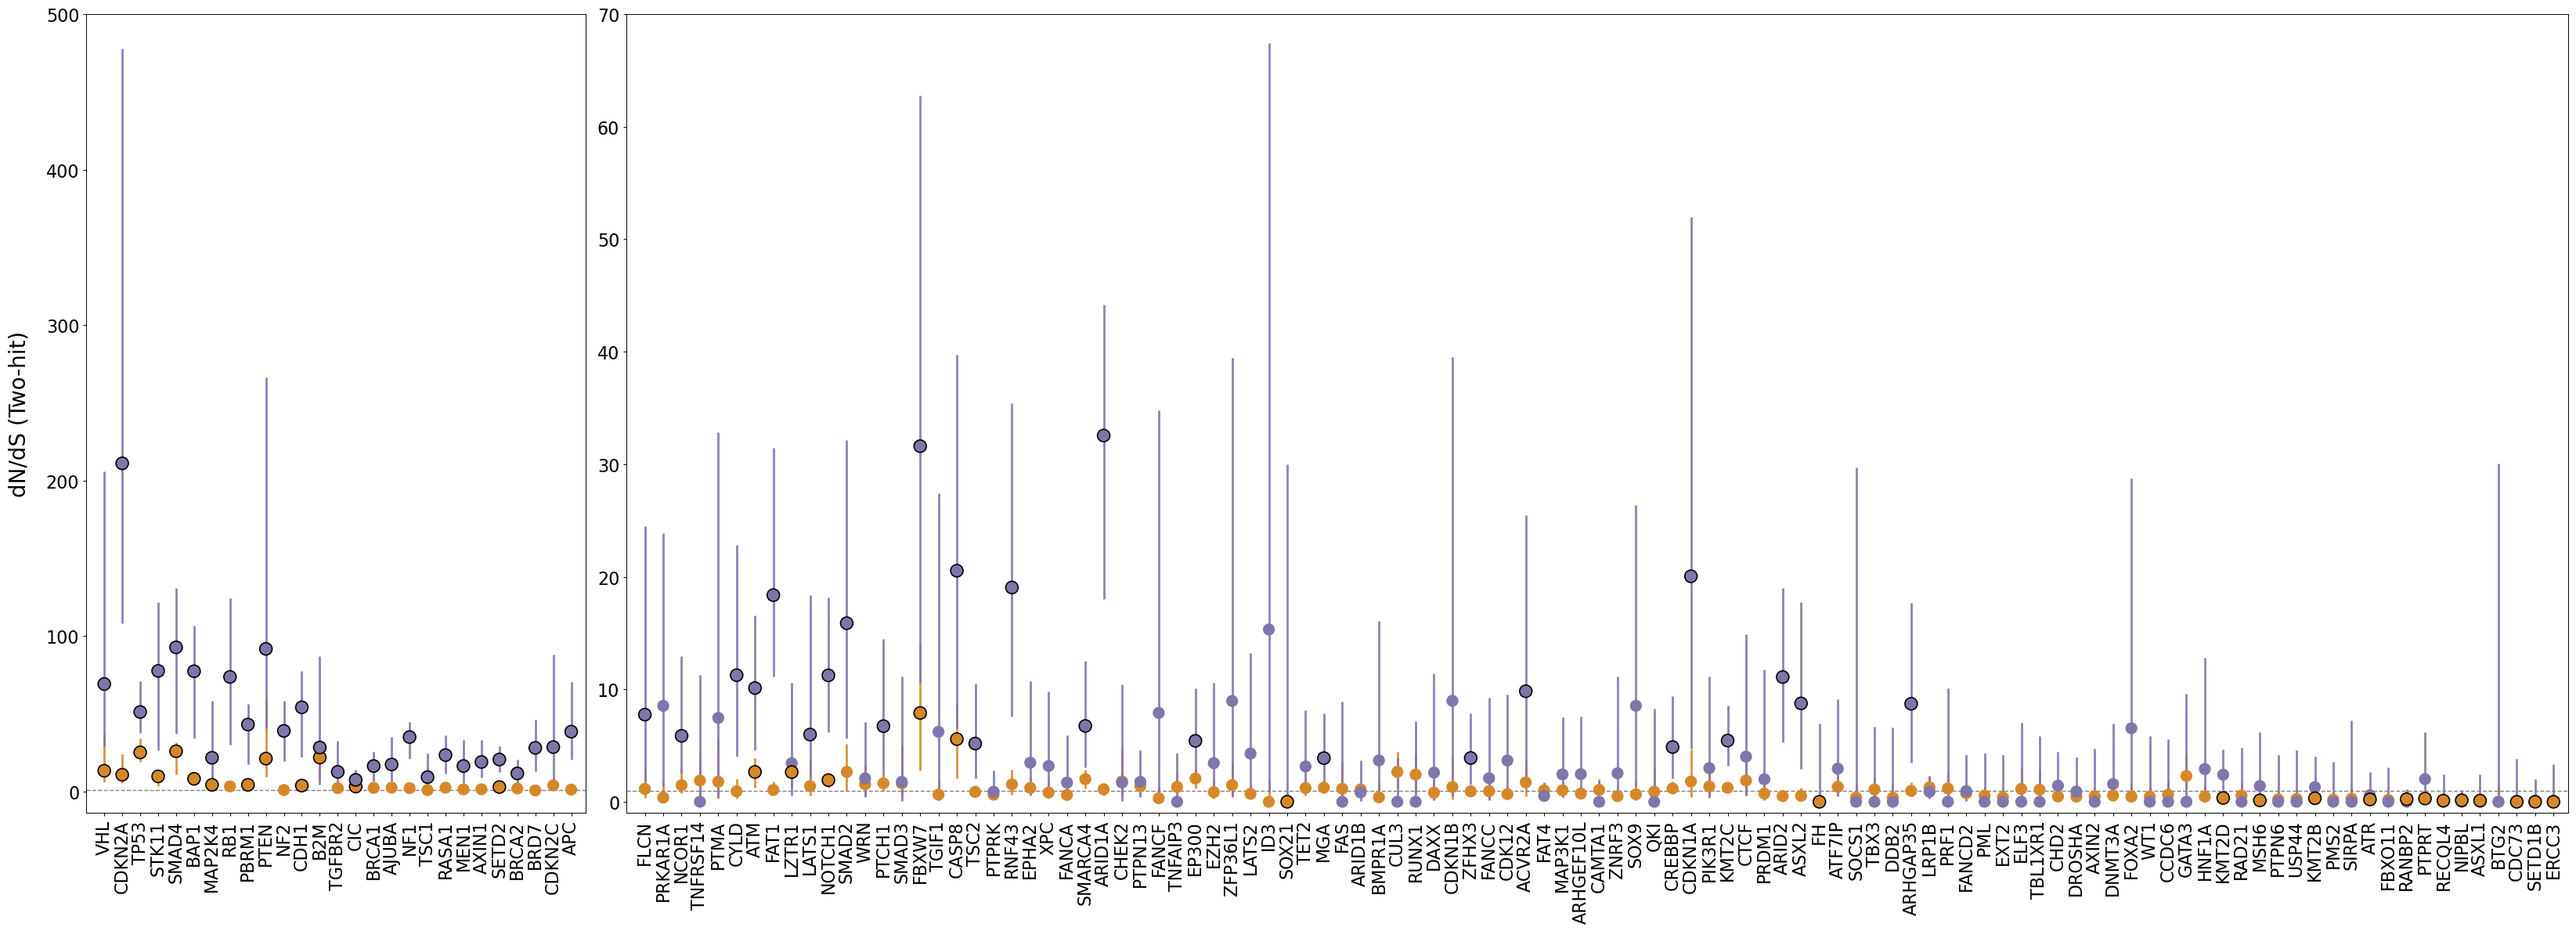

In [6]:
# Two-hit

config_rcparams()

twohit = twohit.copy()

twohit["gene_name"] = twohit["gene_name"].astype(str)
twohit = twohit[twohit["gene_name"] != "nan"]

twohit["class"] = twohit["class"].astype(str).str.strip().str.lower()

twohit["color"] = np.where(
    twohit["class"] == "mis", "#D68829",
    np.where(twohit["class"] == "tru", "#8076AB", "black")
)

gene_order = (
    twohitfreq
    .sort_values("2hitfreq", ascending=False)["gene_name"]
)
gene_order = gene_order[gene_order.isin(twohit["gene_name"])]

twohit["gene_name"] = pd.Categorical(
    twohit["gene_name"],
    categories=list(gene_order),
    ordered=True
)

twohit = twohit.sort_values("gene_name")

twohit_high = twohit[twohit["gene_name"].isin(high)]
twohit_rest = twohit[~twohit["gene_name"].isin(high)]

fig, (ax_left, ax_right) = plt.subplots(
    1, 2,
    figsize=(0.25 * len(gene_order), 12),
    sharey=False,
    gridspec_kw={"width_ratios": [len(twohit_high), len(twohit_rest)]}
)

def plot_panel(ax, df, ylim_max, ylim_min):
    for cls in ["mis", "tru"]:
        df_cls = df[df["class"] == cls]

        x = df_cls["gene_name"]
        y = df_cls["mle"]
        c = df_cls["color"]

        # CI bars
        ax.vlines(
            x=x,
            ymin=df_cls["low"],
            ymax=df_cls["high"],
            colors=c,
            linewidth=2,
            alpha=0.9,
            zorder=1
        )

        # Non-significant
        nonsig = df_cls["qval"] >= 0.05
        ax.scatter(
            x[nonsig],
            y[nonsig],
            c=c[nonsig],
            s=100,
            zorder=3,
            label=cls if cls not in ax.get_legend_handles_labels()[1] else None
        )

        # Significant (outlined)
        sig = df_cls["qval"] < 0.05
        ax.scatter(
            x[sig],
            y[sig],
            c=c[sig],
            edgecolor="black",
            linewidth=1.2,
            s=130,
            zorder=4
        )

    ax.axhline(1, linestyle="--", color="grey", linewidth=1)
    ax.set_ylim(ylim_min, ylim_max)
    ax.tick_params(axis="x", rotation=90)

# Left: high genes
plot_panel(ax_left, twohit_high, ylim_max=500, ylim_min=-14)
ax_left.set_ylabel("dN/dS (Two-hit)", fontsize=20, labelpad=15)

# Right: remaining genes
plot_panel(ax_right, twohit_rest, ylim_max=70, ylim_min=-1)
ax_right.set_ylabel("", fontsize=1)

ax_left.set_xlim(-1, 26.8)
ax_right.set_xlim(-1, 104.8)


for ax in (ax_left, ax_right):
    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)

plt.tight_layout()
plt.show()

---

# Fig S3E

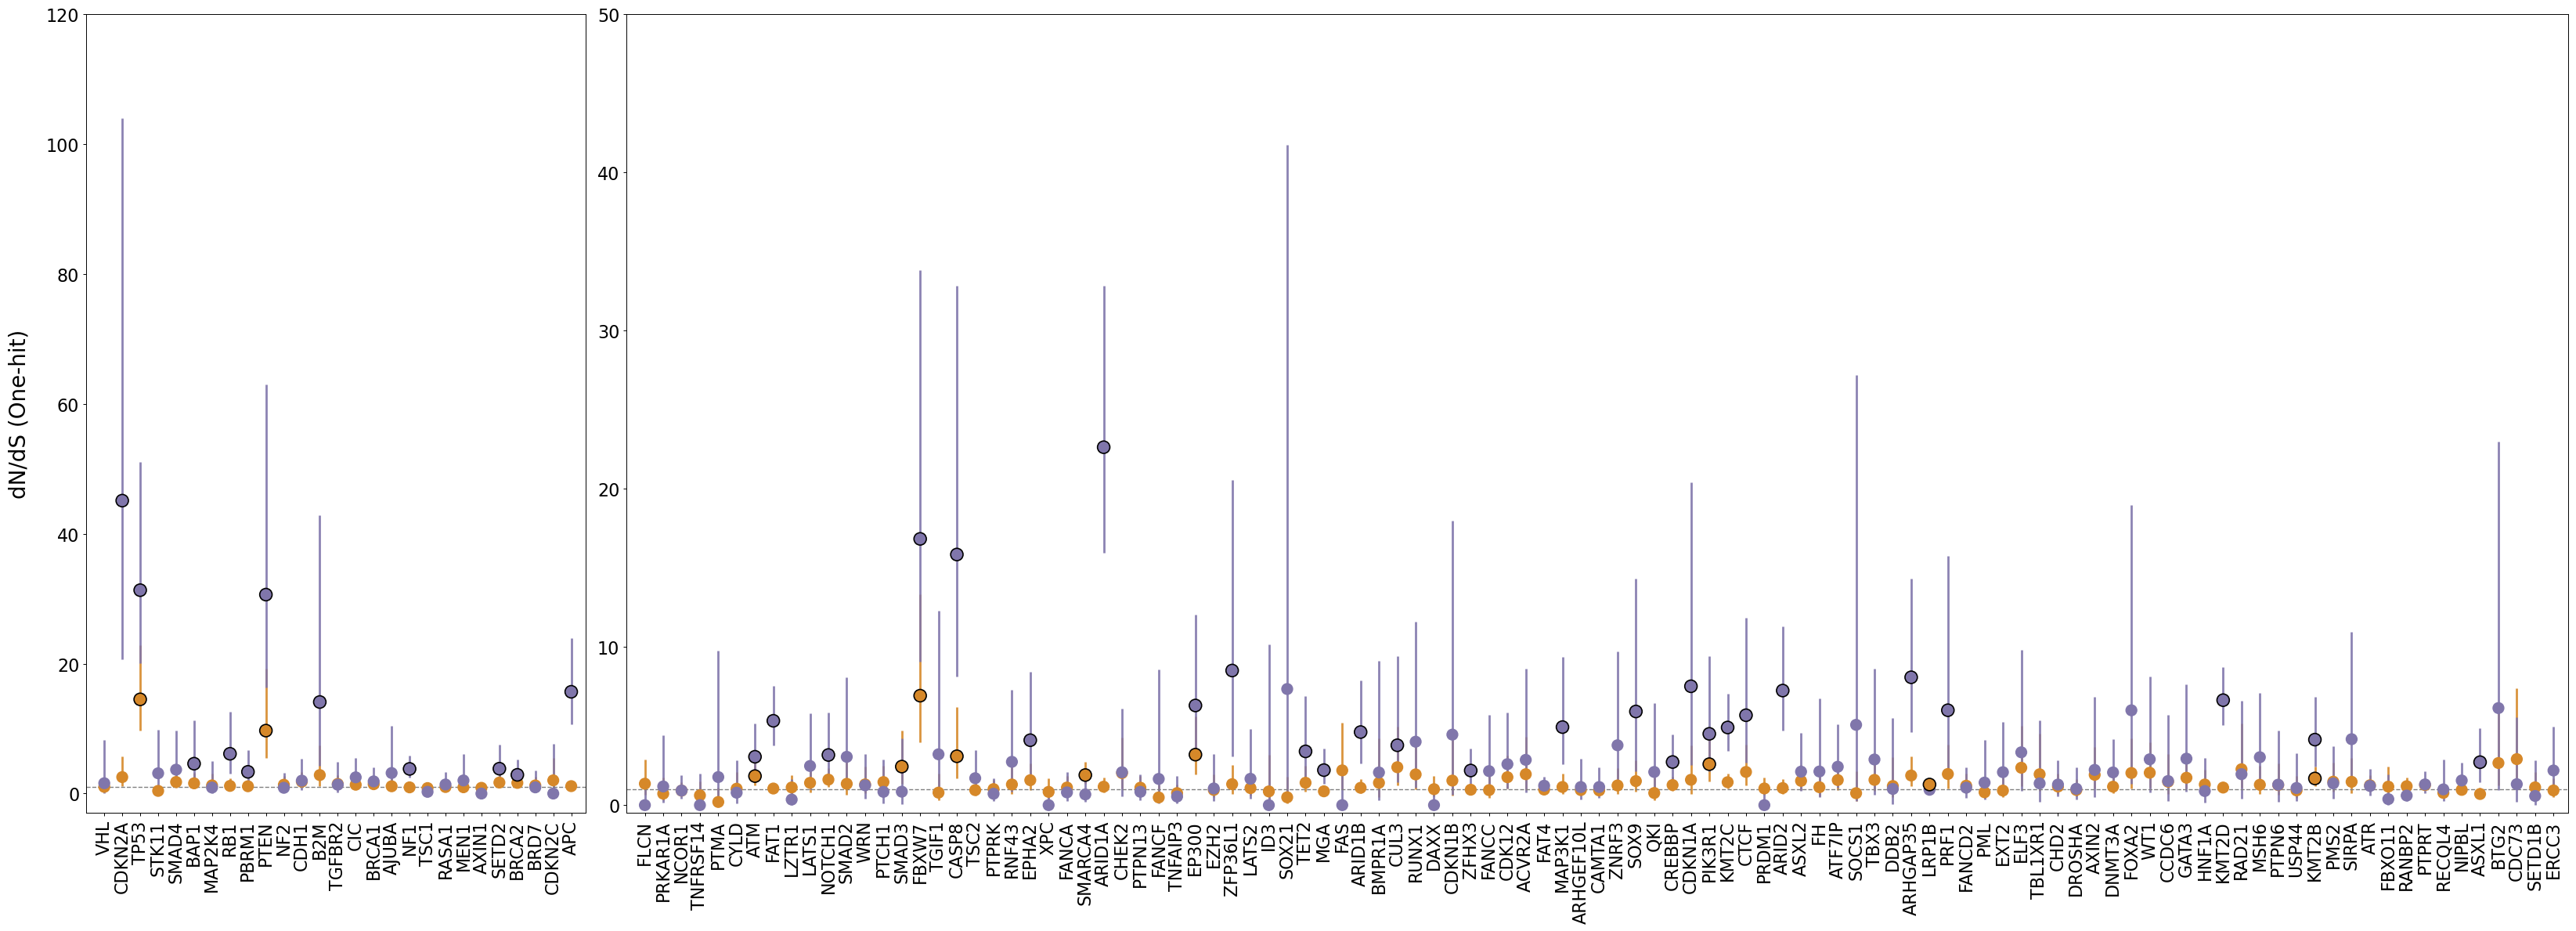

In [7]:
# One-hit 

config_rcparams()

onehit = onehit.copy()

onehit["gene_name"] = onehit["gene_name"].astype(str)
onehit = onehit[onehit["gene_name"] != "nan"]

onehit["class"] = onehit["class"].astype(str).str.strip().str.lower()

# CORRECT colors
onehit["color"] = np.where(
    onehit["class"] == "mis", "#D68829",
    np.where(onehit["class"] == "tru", "#8076AB", "black")
)

# Order genes
gene_order = (
    twohitfreq
    .sort_values("2hitfreq", ascending=False)["gene_name"]
)
gene_order = gene_order[gene_order.isin(onehit["gene_name"])]

onehit["gene_name"] = pd.Categorical(
    onehit["gene_name"],
    categories=list(gene_order),
    ordered=True
)

onehit = onehit.sort_values("gene_name")

onehit_high = onehit[onehit["gene_name"].isin(high)]
onehit_rest = onehit[~onehit["gene_name"].isin(high)]

fig, (ax_left, ax_right) = plt.subplots(
    1, 2,
    figsize=(0.25 * len(gene_order), 12),
    sharey=False,
    gridspec_kw={"width_ratios": [len(onehit_high), len(onehit_rest)]}
)

def plot_panel(ax, df, ylim_max):
    for cls in ["mis", "tru"]:
        df_cls = df[df["class"] == cls]

        x = df_cls["gene_name"]
        y = df_cls["mle"]
        c = df_cls["color"]

        # CI bars
        ax.vlines(
            x=x,
            ymin=df_cls["low"],
            ymax=df_cls["high"],
            colors=c,
            linewidth=2,
            alpha=0.9,
            zorder=1
        )

        # Non-significant
        nonsig = df_cls["qval"] >= 0.05
        ax.scatter(
            x[nonsig],
            y[nonsig],
            c=c[nonsig],
            s=100,
            zorder=3,
            label=cls if cls not in ax.get_legend_handles_labels()[1] else None
        )

        # Significant (outlined)
        sig = df_cls["qval"] < 0.05
        ax.scatter(
            x[sig],
            y[sig],
            c=c[sig],
            edgecolor="black",
            linewidth=1.2,
            s=130,
            zorder=4
        )

    ax.axhline(1, linestyle="--", color="grey", linewidth=1)
    ax.set_ylim(0, ylim_max)
    ax.tick_params(axis="x", rotation=90)

# Left: high genes
plot_panel(ax_left, onehit_high, ylim_max=400)
ax_left.set_ylabel("dN/dS (One-hit)", fontsize=20, labelpad=15)

# Right: remaining genes
plot_panel(ax_right, onehit_rest, ylim_max=60)
ax_right.set_ylabel("", fontsize=1)

# After plotting
ax_left.set_xlim(-1, 26.8)
ax_right.set_xlim(-1, 104.8)

ax_left.set_ylim(-3, 120)
ax_right.set_ylim(-0.5, 50)

for ax in (ax_left, ax_right):
    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)


plt.tight_layout()
plt.show()

---

# Fig 2B

In [8]:
# preparing dataset

globaldnds['name'] = globaldnds['name'].apply(lambda x:x[1:])
globaldnds_onehit = globaldnds[globaldnds['hit']=='1-hit']
globaldnds_twohit = globaldnds[globaldnds['hit']=='2-hit']

/tmp/ipykernel_2366/1625508729.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  globaldnds_twohit["category"] = pd.Categorical(
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


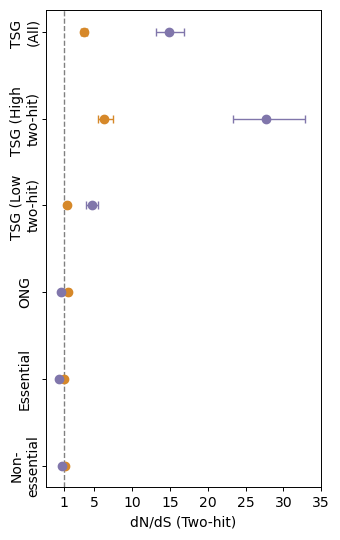

In [9]:
# Two-hit

config_rcparams()

categories_reversed = list(
    globaldnds_twohit["category"].unique()
)[::-1]

globaldnds_twohit["category"] = pd.Categorical(
    globaldnds_twohit["category"],
    categories=categories_reversed,
    ordered=True
)

# Numeric y positions
y_positions = np.arange(len(categories_reversed))

# Color map
color_map = {
    "mis": "#D68829",   # orange
    "tru": "#8076AB"    # purple
}

fig, ax = plt.subplots(figsize=(3.5, 5.5))

for mut_type, df_sub in globaldnds_twohit.groupby("name"):
    y = df_sub["category"].cat.codes
    x = df_sub["mle"]
    xerr = [
        x - df_sub["cilow"],
        df_sub["cihigh"] - x
    ]

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        fmt="o",
        color=color_map[mut_type],
        ecolor=color_map[mut_type],
        elinewidth=1,
        capsize=3,
        markersize=6
    )

# Axis formatting
ax.set_yticks(y_positions)
ax.set_yticklabels(categories_reversed)

# Reference line
ax.axvline(1, linestyle="--", color="grey", linewidth=1)

# Remove legend
ax.set_yticklabels(['Non-\nessential','Essential','ONG','TSG (Low \ntwo-hit)','TSG (High \ntwo-hit)','TSG \n(All)'], rotation=90, ha="center", va="center")
ax.set_xlabel("dN/dS (Two-hit)")
ax.tick_params(axis="y", pad=12)

ax.set_xticks([ 1, 5, 10, 15, 20, 25, 30, 35])
ax.set_xticklabels([ 1, 5, 10, 15, 20, 25, 30, 35])

plt.tight_layout()

plt.show()

---

# Fig S3F

/tmp/ipykernel_2366/1776814220.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  globaldnds_onehit["category"] = pd.Categorical(


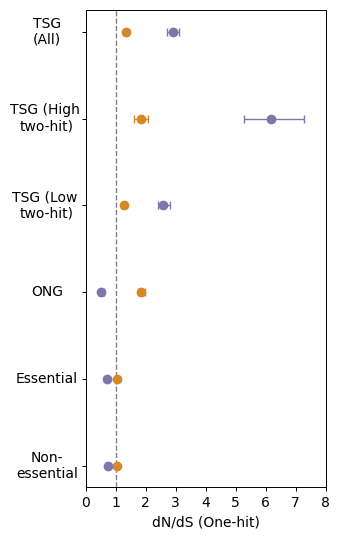

In [10]:
# One-hit

config_rcparams()

categories_reversed = list(
    globaldnds_onehit["category"].unique()
)[::-1]

globaldnds_onehit["category"] = pd.Categorical(
    globaldnds_onehit["category"],
    categories=categories_reversed,
    ordered=True
)

# Numeric y positions
y_positions = np.arange(len(categories_reversed))

# Color map
color_map = {
    "mis": "#D68829",   # orange
    "tru": "#8076AB"    # purple
}

fig, ax = plt.subplots(figsize=(3.5, 5.5))

for mut_type, df_sub in globaldnds_onehit.groupby("name"):
    y = df_sub["category"].cat.codes
    x = df_sub["mle"]
    xerr = [
        x - df_sub["cilow"],
        df_sub["cihigh"] - x
    ]

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        fmt="o",
        color=color_map[mut_type],
        ecolor=color_map[mut_type],
        elinewidth=1,
        capsize=3,
        markersize=6
    )

# Axis formatting
ax.set_yticks(y_positions)
ax.set_yticklabels(categories_reversed)

# Reference line
ax.axvline(1, linestyle="--", color="grey", linewidth=1)

# Remove legend
ax.legend_.remove() if ax.legend_ else None

ax.set_yticklabels(['Non-\nessential','Essential','ONG','TSG (Low \ntwo-hit)','TSG (High \ntwo-hit)','TSG\n(All)'], rotation=90, ha="center", va="center")
ax.set_xlabel("dN/dS (One-hit)")
ax.tick_params(axis="y", pad=25)

ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8])
ax.set_xticklabels([0, 1, 2, 3, 4, 5, 6, 7, 8])
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

---

# Fig S3A

In [11]:
# preparing dataset

twohitscatter = pd.merge(twohitfreq[['gene_name','2hitfreq']],twohit[['gene_name','class','mle']],on='gene_name')
onehitscatter = pd.merge(twohitfreq[['gene_name','2hitfreq']],onehit[['gene_name','class','mle']],on='gene_name')

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


SignificanceResult(statistic=0.7913890301290473, pvalue=1.4389966070161715e-29)


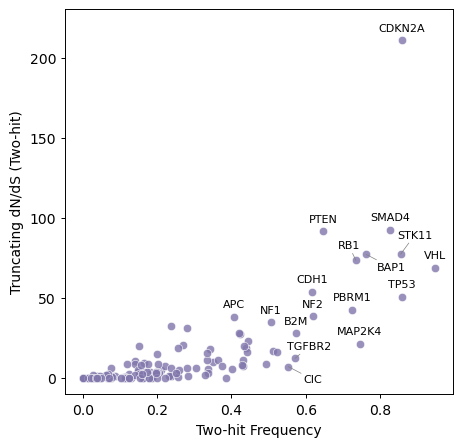

In [12]:
config_rcparams()

plt.figure(figsize=(5,5))

genes_to_annotate = {
    "BAP1":(18,-18),
    "STK11":(10,5),
    "CIC":(18,-18),
    "TGFBR2":(10,0),
    "RB1":(-5,2)
}

data = twohitscatter[twohitscatter['class']=='tru'].copy()
print(stats.spearmanr(data['2hitfreq'].values,data['mle'].values))
ax = sns.scatterplot(data=data,x='2hitfreq',y='mle', color='#8076AB', alpha=0.8)
plt.ylabel('Truncating dN/dS (Two-hit)')
plt.xlabel('Two-hit Frequency')

labelled = data[(data['mle'] >= 33)|(data['2hitfreq'] >= 0.55)]

for _, row in labelled.iterrows():
    x, y = row['2hitfreq'], row['mle']
    label = row['gene_name']
    dx, dy = (0, 5)

    if label in genes_to_annotate:
        extra_dx, extra_dy = genes_to_annotate[label]
        dx += extra_dx
        dy += extra_dy

        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=8,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=8,
            ha="center", va="bottom",          
        )
        
plt.ylim(-10,230)  
plt.show()

---

# Fig S3B

SignificanceResult(statistic=0.7490287457109537, pvalue=5.30221536792541e-25)


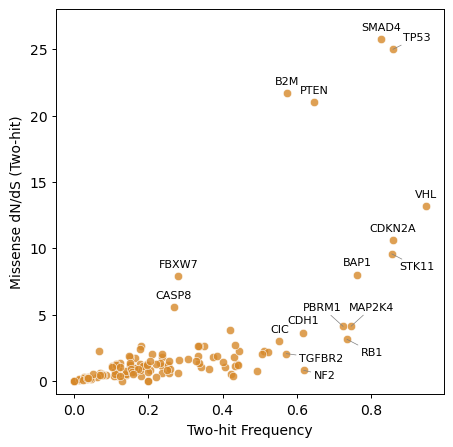

In [13]:
config_rcparams()

plt.figure(figsize=(5,5))

genes_to_annotate = {
    "STK11":(18,-18),
    "RB1":(18,-18),
    "PBRM1":(-15,5),
    "TGFBR2":(25,-12),
    "NF2":(15,-12),
    "TP53":(17,0),
    "MAP2K4":(15,5),
}

data = twohitscatter[twohitscatter['class']=='mis'].copy()
print(stats.spearmanr(data['2hitfreq'].values,data['mle'].values))

ax = sns.scatterplot(data=data,x='2hitfreq',y='mle', color='#D68829', alpha=0.8)

labelled = data[(data['mle'] >= 4)|(data['2hitfreq'] >= 0.55)]

for _, row in labelled.iterrows():
    x, y = row['2hitfreq'], row['mle']
    label = row['gene_name']
    dx, dy = (0, 5)

    if label in genes_to_annotate:
        extra_dx, extra_dy = genes_to_annotate[label]
        dx += extra_dx
        dy += extra_dy

        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=8,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=8,
            ha="center", va="bottom",          
        )
        

plt.ylim(-1,28) 

plt.ylabel('Missense dN/dS (Two-hit)')
plt.xlabel('Two-hit Frequency')

plt.show()

---

# Fig S3C

SignificanceResult(statistic=0.050971336541990916, pvalue=0.5616289652380967)


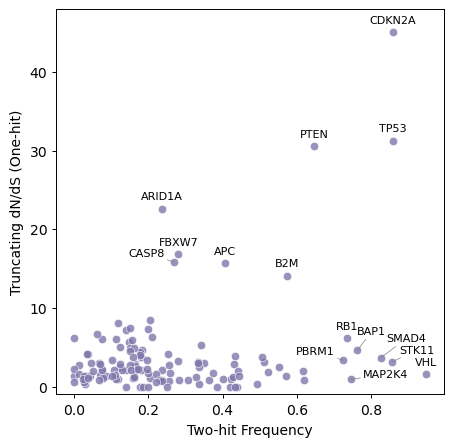

In [14]:
# Fig S3Aconfig_rcparams()

plt.figure(figsize=(5,5))

genes_to_annotate = {
    "SMAD4":(18,5),
    "STK11":(18,0),
    "MAP2K4":(25,-5),
    "BAP1":(10,5),
    "CASP8":(-20,-2),
    "PBRM1":(-20,-2),
}

data = onehitscatter[onehitscatter['class']=='tru'].copy()
print(stats.spearmanr(data['2hitfreq'].values,data['mle'].values))
ax = sns.scatterplot(data=data,x='2hitfreq',y='mle', color='#8076AB', alpha=0.8)

labelled = data[(data['mle'] >= 10)|(data['2hitfreq'] >= 0.7)]

for _, row in labelled.iterrows():
    x, y = row['2hitfreq'], row['mle']
    label = row['gene_name']
    dx, dy = (0, 5)

    if label in genes_to_annotate:
        extra_dx, extra_dy = genes_to_annotate[label]
        dx += extra_dx
        dy += extra_dy

        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=8,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=8,
            ha="center", va="bottom",          
        )
        
plt.ylim(-1,48) 
        
plt.ylabel('Truncating dN/dS (One-hit)')
plt.xlabel('Two-hit Frequency')

plt.show()

---

# Fig S3D

SignificanceResult(statistic=-0.016913865306538607, pvalue=0.8473576080003122)


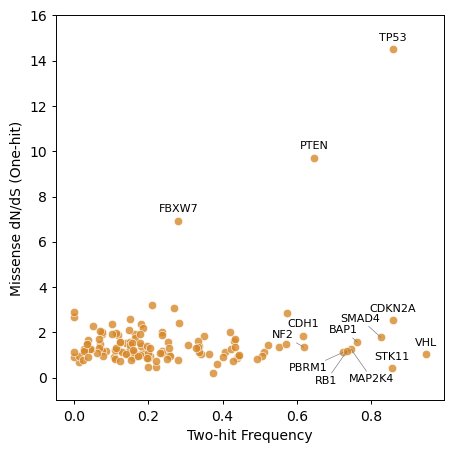

In [16]:
# Fig S3Aconfig_rcparams()

plt.figure(figsize=(5,5))

genes_to_annotate = {
     "MAP2K4":(15,-30),
     "PBRM1":(-25,-20),
     "RB1":(-15,-30),
     "BAP1":(-10,0),
     "NF2":(-15,0),
     "SMAD4":(-15,5),
}

data = onehitscatter[onehitscatter['class']=='mis'].copy()
print(stats.spearmanr(data['2hitfreq'].values,data['mle'].values))
ax = sns.scatterplot(data=data,x='2hitfreq',y='mle',  color='#D68829', alpha=0.8)

labelled = data[(data['mle'] >= 4)|(data['2hitfreq'] >= 0.6)]

for _, row in labelled.iterrows():
    x, y = row['2hitfreq'], row['mle']
    label = row['gene_name']
    dx, dy = (0, 5)

    if label in genes_to_annotate:
        extra_dx, extra_dy = genes_to_annotate[label]
        dx += extra_dx
        dy += extra_dy

        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=8,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=8,
            ha="center", va="bottom",          
        )
        
plt.ylim(-1,16)
plt.ylabel('Missense dN/dS (One-hit)')
plt.xlabel('Two-hit Frequency')

plt.show()

---